<a href="https://colab.research.google.com/github/GayatriVidhate23/Machine--Vision-Practical/blob/main/prc_2(mv).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving prmv.jpg to prmv.jpg


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

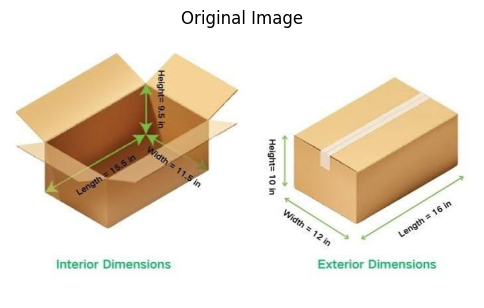

In [4]:
image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

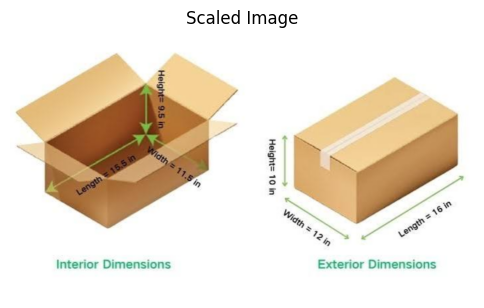

In [5]:
scale = 1.5

scaled = cv2.resize(
    img,
    None,
    fx=scale,
    fy=scale,
    interpolation=cv2.INTER_LINEAR
)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB))
plt.title("Scaled Image")
plt.axis("off")
plt.show()

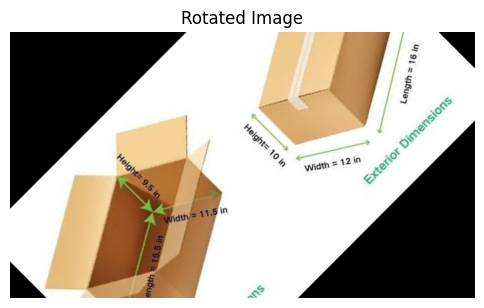

In [6]:
height, width = img.shape[:2]

center = (width//2, height//2)

rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1)

rotated = cv2.warpAffine(
    img,
    rotation_matrix,
    (width, height)
)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
plt.title("Rotated Image")
plt.axis("off")
plt.show()

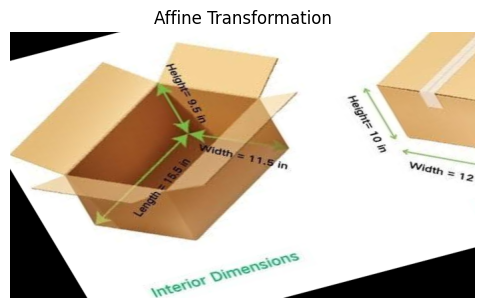

In [7]:
rows, cols = img.shape[:2]

pts1 = np.float32([
    [50,50],
    [200,50],
    [50,200]
])

pts2 = np.float32([
    [10,100],
    [200,50],
    [100,250]
])

matrix = cv2.getAffineTransform(pts1, pts2)

affine = cv2.warpAffine(
    img,
    matrix,
    (cols, rows)
)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(affine, cv2.COLOR_BGR2RGB))
plt.title("Affine Transformation")
plt.axis("off")
plt.show()

Width : 72 pixels
Height: 61 pixels
Width : 36 pixels
Height: 41 pixels
Width : 146 pixels
Height: 93 pixels
Width : 243 pixels
Height: 146 pixels


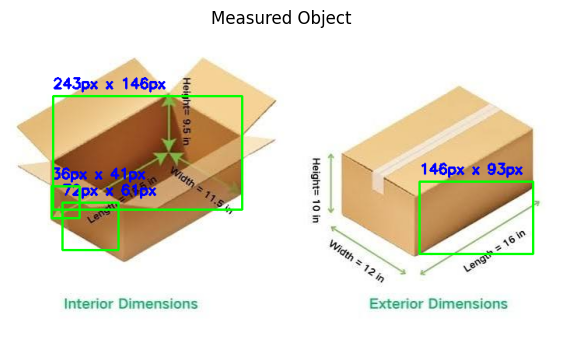

In [8]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(
    gray,
    120,
    255,
    cv2.THRESH_BINARY_INV
)

contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

output = img.copy()

for cnt in contours:

    if cv2.contourArea(cnt) > 500:

        x, y, w, h = cv2.boundingRect(cnt)

        cv2.rectangle(
            output,
            (x,y),
            (x+w,y+h),
            (0,255,0),
            2
        )

        cv2.putText(
            output,
            f"{w}px x {h}px",
            (x,y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255,0,0),
            2
        )

        print("Width :", w, "pixels")
        print("Height:", h, "pixels")

plt.figure(figsize=(7,7))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Measured Object")
plt.axis("off")
plt.show()